In [1]:
import os
import glob
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. List all files in the Kaggle input directory
input_path = '/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge'
print("--- Files in Input Directory ---")
for dirname, _, filenames in os.walk(input_path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

--- Files in Input Directory ---
/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/telemetry_2026-01-11_2026-01-20.parquet
/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/rfid_refuels_2026-01-01_2026-02-28.parquet
/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/telemetry_2026-02-11_2026-02-20.parquet
/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/mine_002_anonymized.gpkg
/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/mine_001_anonymized.gpkg
/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/telemetry_2026-01-01_2026-01-10.parquet
/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/id_mapping.csv
/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/sample_telemetry.csv
/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/telemetry_2026-02-21_2026-02-28.parquet
/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/telemetr


Sample Telemetry File Analysis
Sample data shape: (72693, 37)


,ts,received_ts,altitude,speed,ignition,angle,lls_1_fuel_level,lls_2_fuel_level,lls_3_fuel_level,lls_4_fuel_level,...,fuel_volume_digital,fuel_volume_analog,fuel_volume_analog_1,.fuel_sensor_type,fuel_volume,floorval,lon2,lat2,mine_anon,vehicle_anon
0,2026-03-24 09:00:00,2026-03-24 09:04:00,663,0,0,281,808.0,NaN,NaN,NaN,...,1096.153846,NaN,NaN,digital,1096.153846,110.384615,85.860766,21.657653,mine003,Dump045
1,2026-03-24 09:00:00,2026-03-24 09:01:09,631,0,0,121,424.0,NaN,NaN,NaN,...,579.729730,NaN,NaN,digital,579.729730,58.108108,85.726608,21.655013,mine002,Dump033
2,2026-03-24 09:00:00,2026-03-24 09:00:32,648,0,0,147,437.0,NaN,NaN,NaN,...,597.297297,NaN,NaN,digital,597.297297,60.000000,85.726431,21.654881,mine002,Dump038


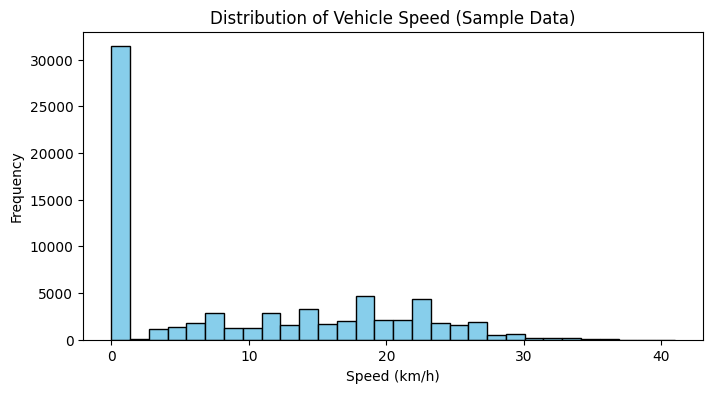

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72693 entries, 0 to 72692
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ts                    72693 non-null  datetime64[ns]
 1   received_ts           72693 non-null  object        
 2   altitude              72693 non-null  int64         
 3   speed                 72693 non-null  int64         
 4   ignition              72693 non-null  int64         
 5   angle                 72693 non-null  int64         
 6   lls_1_fuel_level      71094 non-null  float64       
 7   lls_2_fuel_level      527 non-null    float64       
 8   lls_3_fuel_level      527 non-null    float64       
 9   lls_4_fuel_level      527 non-null    float64       
 10  satellites            72693 non-null  int64         
 11  gnss_pdop             72693 non-null  float64       
 12  gsm_signal            72693 non-null  int64         
 13  gsm_operator    

In [3]:
# 2. Load and inspect the sample telemetry CSV
print("\nSample Telemetry File Analysis")
csv_files = glob.glob(f'{input_path}/**/*.csv', recursive=True)
if csv_files:
    sample_df = pd.read_csv(csv_files[1])
    
    # Converting 'ts' to correct format
    sample_df['ts'] = pd.to_datetime(sample_df['ts'])
    print(f"Sample data shape: {sample_df.shape}")
    display(sample_df.head(3))
    
    # Quick visual: Speed distribution
    plt.figure(figsize=(8, 4))
    plt.hist(sample_df['speed'].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title('Distribution of Vehicle Speed (Sample Data)')
    plt.xlabel('Speed (km/h)')
    plt.ylabel('Frequency')
    plt.show()
    sample_df.info()


Spatial Map Analysis


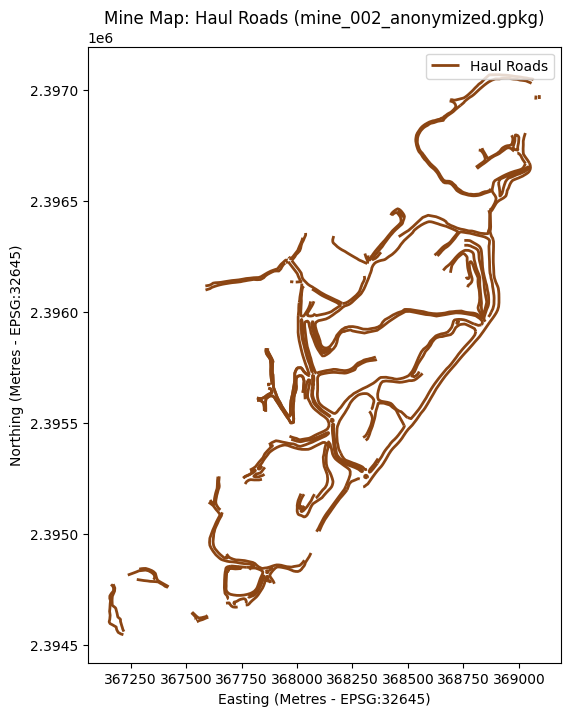

Found layers: ['bench', 'cpu', 'ecr', 'haul_road', 'ml_boundary', 'mineral_stock', 'nh_road', 'ob_dump', 'office', 'village_road']


/tmp/ipykernel_17/16992844.py:44: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


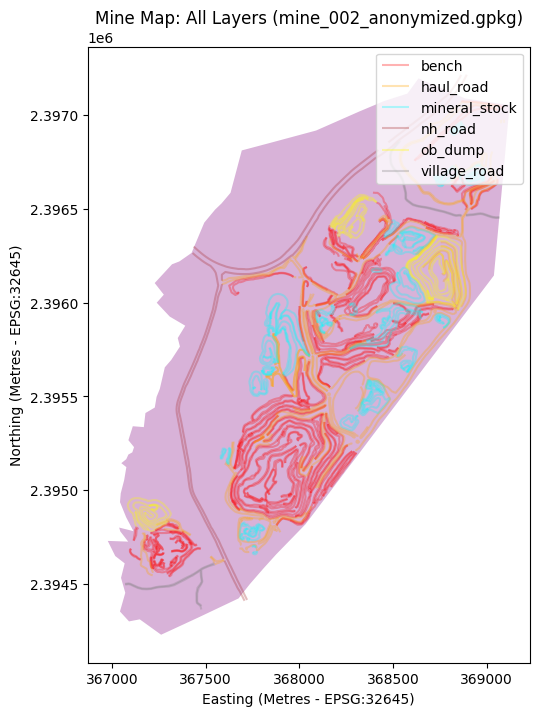

In [4]:
# 3. Load and inspect the GeoPackage Map (e.g., mine_001_anonymized.gpkg)
print("\nSpatial Map Analysis")
gpkg_files = glob.glob(f'{input_path}/**/*.gpkg', recursive=True)
if gpkg_files:
    map_file = gpkg_files[0]
    
    try:
        haul_roads = gpd.read_file(map_file, layer='haul_road')
        
        fig, ax = plt.subplots(figsize=(10, 8))
        haul_roads.plot(ax=ax, color='saddlebrown', linewidth=2, label='Haul Roads')
        ax.set_title(f'Mine Map: Haul Roads ({os.path.basename(map_file)})')
        ax.set_xlabel('Easting (Metres - EPSG:32645)')
        ax.set_ylabel('Northing (Metres - EPSG:32645)')
        plt.legend()
        plt.show()
    except Exception as e:
        print(f"Could not load haul_road layer: {e}")

#plotting all layers
color_list = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'brown', 'yellow', 'pink', 'gray']

import fiona
if gpkg_files:
    map_file = gpkg_files[0]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    layers = fiona.listlayers(map_file)
    print(f"Found layers: {layers}")
    
    for i, layer in enumerate(layers):
        try:
            gdf = gpd.read_file(map_file, layer=layer)
            if not gdf.empty:
                color = color_list[i % len(color_list)]
                gdf.plot(ax=ax, label=layer, alpha=0.3, color=color)
        except Exception as e:
            print(f"Could not load layer {layer}: {e}")

    ax.set_title(f"Mine Map: All Layers ({os.path.basename(map_file)})")
    ax.set_xlabel("Easting (Metres - EPSG:32645)")
    ax.set_ylabel("Northing (Metres - EPSG:32645)")
    plt.legend()
    plt.show()

In [5]:
def preprocess_telemetry(df):
    """
    Applies required preprocessing to telemetry data based on the Problem Statement.
    """
    df['ts'] = pd.to_datetime(df['ts'])
    df['working_date'] = (df['ts'] + pd.Timedelta(hours=2)).dt.date
    df_clean = df.dropna(subset=['latitude', 'longitude']).copy()

    gdf = gpd.GeoDataFrame(
        df_clean, 
        geometry=gpd.points_from_xy(df_clean.longitude, df_clean.latitude),
        crs="EPSG:4326"
    )
    
    gdf = gdf.to_crs(epsg=32645)
    gdf['x_m'] = gdf.geometry.x
    gdf['y_m'] = gdf.geometry.y
    
    return pd.DataFrame(gdf)

In [6]:
import pandas as pd
import glob
import numpy as np

targets = [
    'fuel_volume', 'prod_hr_dpr', 'idle_hr_dpr', 
    'maint_hr_dpr', 'bd_hr_dpr', 'hmr_dpr', 
    'km_dpr', 'tonnage'
]

print("--- Preparing Refuel Data ---")
refuel_files = glob.glob('/kaggle/input/**/rfid_refuels*.parquet', recursive=True)

if refuel_files:
    print(f"Loading refuels from: {refuel_files[0]}")
    df_refuels = pd.read_parquet(refuel_files[0])
    df_refuels['ts'] = pd.to_datetime(df_refuels['ts'])
    df_refuels['working_date'] = (df_refuels['ts'] + pd.Timedelta(hours=2)).dt.date
    daily_refuels = df_refuels.groupby(['vehicle', 'working_date'])['litres'].sum().reset_index()
else:
    print("Warning: Refuel file not found. Ensure the path is correct.")
    daily_refuels = pd.DataFrame(columns=['vehicle', 'working_date', 'litres'])


print("\n--- Calculating True Fuel Consumption from Train Set ---")

all_parquet_files = glob.glob('/kaggle/input/**/*.parquet', recursive=True)

train_dates = [
    '2026-01-01_2026-01-10', 
    '2026-01-11_2026-01-20', 
    '2026-02-01_2026-02-10', 
    '2026-02-11_2026-02-20'
]

train_files = [f for f in all_parquet_files if any(d in f for d in train_dates)]

if not train_files:
    raise ValueError("Could not find the training files! Please check your file paths.")
else:
    print(f"Found {len(train_files)} training files.")

daily_train_records = []

# Process the first 2 chunks for our baseline
for file in train_files[:2]: 
    print(f"Processing {file.split('/')[-1]}...")
    df_chunk = pd.read_parquet(file)
    processed_chunk = preprocess_telemetry(df_chunk)
    
    processed_chunk = processed_chunk.sort_values(by=['vehicle', 'ts'])
    
    for (veh, date), group in processed_chunk.groupby(['vehicle', 'working_date']):
        
        smoothed_fuel = group['fuel_volume'].rolling(window=10, min_periods=1).median()
        if smoothed_fuel.dropna().empty:
            continue
            
        start_fuel = smoothed_fuel.dropna().iloc[0]
        end_fuel = smoothed_fuel.dropna().iloc[-1]
        
        refuel_row = daily_refuels[(daily_refuels['vehicle'] == veh) & (daily_refuels['working_date'] == date)]
        refuel_amount = refuel_row['litres'].values[0] if not refuel_row.empty else 0.0
        
        daily_consumption = (start_fuel - end_fuel) + refuel_amount
        
        daily_consumption = max(0, daily_consumption)
        
        daily_train_records.append({
            'vehicle': veh,
            'working_date': date,
            'fuel_volume': daily_consumption 
        })

full_train_daily = pd.DataFrame(daily_train_records)

# Calculate the Vehicle-Specific Means
vehicle_fuel_means = full_train_daily.groupby('vehicle')['fuel_volume'].mean().to_dict()
global_fuel_mean = full_train_daily['fuel_volume'].mean()

print("\n--- True Vehicle-Specific Average Consumption (with Refuels) ---")
for k, v in list(vehicle_fuel_means.items())[:5]:
    print(f"{k}: {v:.2f} Liters")

--- Preparing Refuel Data ---
Loading refuels from: /kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/rfid_refuels_2026-01-01_2026-02-28.parquet

--- Calculating True Fuel Consumption from Train Set ---
Found 4 training files.
Processing telemetry_2026-01-11_2026-01-20.parquet...
Processing telemetry_2026-02-11_2026-02-20.parquet...

--- True Vehicle-Specific Average Consumption (with Refuels) ---
Dump002: 177.04 Liters
Dump012: 162.64 Liters
Dump016: 137.62 Liters
Dump017: 719.63 Liters
Dump018: 653.43 Liters


Reading /kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/telemetry_2026-01-01_2026-01-10.parquet...
Data loaded: (4334181, 39)
Vehicle: Dump023
Date: 2026-01-05
Data points: 20259
Fuel volume range: 472.37 - 1098.72 liters


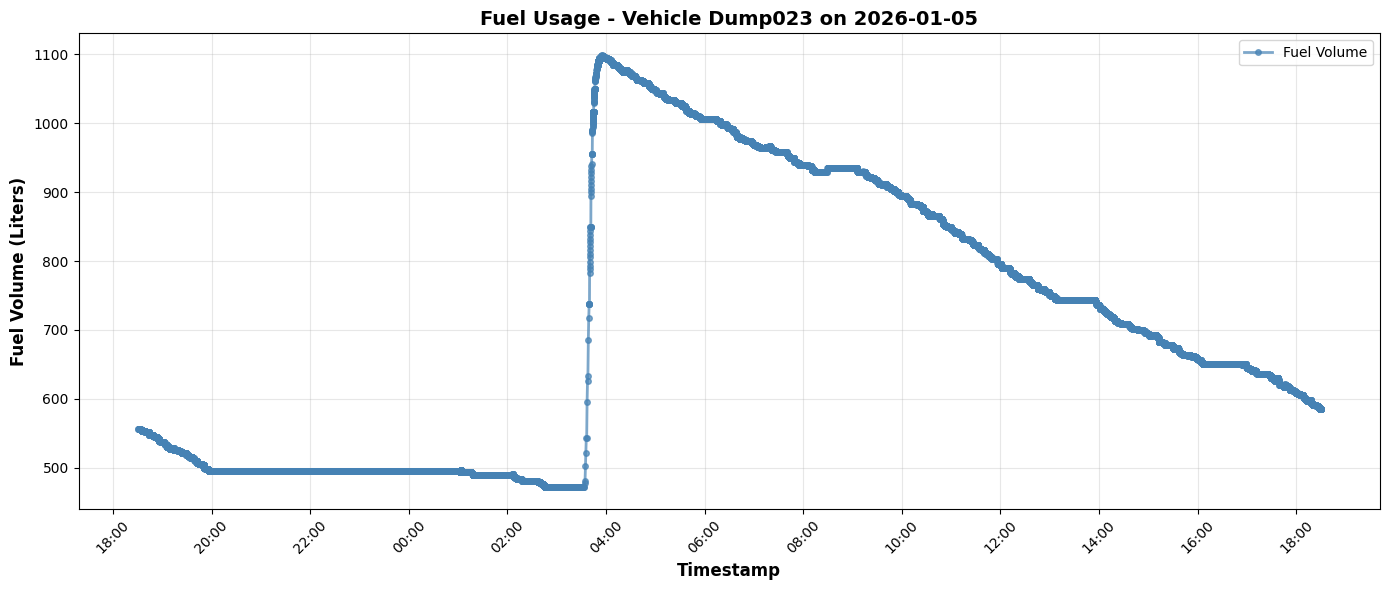

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ===== CHANGE THESE PARAMETERS =====
# Specify the parquet file to read
parquet_file = '/kaggle/input/competitions/mindshift-analytics-haul-mark-challenge/telemetry_2026-01-01_2026-01-10.parquet'  # Change to desired file
# Select date (format: 'YYYY-MM-DD')
selected_date = '2026-01-05'  # Change this to any date you want
# Select vehicle (or use None to get first vehicle)
selected_vehicle = None  # Change to vehicle name like 'Dump023' or leave as None for first vehicle
# ====================================

# Read the parquet file
print(f"Reading {parquet_file}...")
telemetry_data = pd.read_parquet(parquet_file)
print(f"Data loaded: {telemetry_data.shape}")

sample_date = pd.to_datetime(selected_date).date()
sample_vehicle = selected_vehicle if selected_vehicle else telemetry_data['vehicle'].iloc[0]

# Filter data for the selected vehicle and date
vehicle_day_data = telemetry_data[
    (telemetry_data['vehicle'] == sample_vehicle) & 
    (pd.to_datetime(telemetry_data['ts']).dt.date == sample_date)
].copy()

# Sort by timestamp
vehicle_day_data = vehicle_day_data.sort_values('ts')

print(f"Vehicle: {sample_vehicle}")
print(f"Date: {sample_date}")
print(f"Data points: {len(vehicle_day_data)}")
print(f"Fuel volume range: {vehicle_day_data['fuel_volume'].min():.2f} - {vehicle_day_data['fuel_volume'].max():.2f} liters")

# Create the plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(pd.to_datetime(vehicle_day_data['ts']), vehicle_day_data['fuel_volume'], 
        marker='o', linewidth=2, markersize=4, color='steelblue', alpha=0.7, label='Fuel Volume')

# Formatting
ax.set_xlabel('Timestamp', fontsize=12, fontweight='bold')
ax.set_ylabel('Fuel Volume (Liters)', fontsize=12, fontweight='bold')
ax.set_title(f'Fuel Usage - Vehicle {sample_vehicle} on {sample_date}', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Format x-axis to show time nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# test_files = [f for f in all_files if '2026-01-21_2026-01-31' in f or '2026-02-21_2026-02-28' in f]

# print("\n--- Processing Test Set for Submission ---")
# test_combinations = []

# for file in test_files:
#     print(f"Loading {file.split('/')[-1]}...")
#     df_chunk = pd.read_parquet(file)
#     processed_chunk = preprocess_telemetry(df_chunk)
    
#     # Extract just the unique vehicle + date combinations that need predictions
#     unique_combos = processed_chunk[['vehicle', 'working_date']].drop_duplicates()
#     test_combinations.append(unique_combos)


# submission_df = pd.concat(test_combinations).drop_duplicates().reset_index(drop=True)


# submission_df['ID'] = submission_df['vehicle'].astype(str) + '_' + submission_df['working_date'].astype(str)

# for target in targets:
#     submission_df[target] = target_means[target]

# final_submission = submission_df[['ID'] + targets]

# print("\n--- Final Submission Preview ---")
# display(final_submission.head())

# final_submission.to_csv('submission.csv', index=False)
# print("\nSuccess: 'submission.csv' has been saved and is ready to submit!")

In [9]:
# print("\nGenerating Final Submission as global mean")

# id_map_path = glob.glob('/kaggle/input/datasets/sharankeshavs/id-mapping/id_mapping.csv', recursive=True)[0]
# df_id_map = pd.read_csv(id_map_path)

# if 'date' in df_id_map.columns:
#     df_id_map['date'] = pd.to_datetime(df_id_map['date']).dt.date

# if 'target' in df_id_map.columns:
#     df_id_map['Predicted'] = df_id_map['target'].map(target_means)
    
# else:
#     df_id_map['Predicted'] = target_means['fuel_volume']

# final_submission = df_id_map[['id', 'Predicted']] 

# final_submission = final_submission.fillna(0)

# display(final_submission.head())

# final_submission.to_csv('submission.csv', index=False)
# print("submission.csv successfully saved and ready for Kaggle!")

In [10]:
print("\n--- Generating Final Submission ---")

id_map_path = glob.glob('/kaggle/input/**/id_mapping.csv', recursive=True)[0]
df_id_map = pd.read_csv(id_map_path)

if 'date' in df_id_map.columns:
    df_id_map['date'] = pd.to_datetime(df_id_map['date']).dt.date

df_id_map['Predicted'] = df_id_map['vehicle'].map(vehicle_fuel_means)

df_id_map['Predicted'] = df_id_map['Predicted'].fillna(global_fuel_mean)

final_submission = df_id_map[['id', 'Predicted']] 

final_submission = final_submission.fillna(0)

display(final_submission.head())

final_submission.to_csv('submission.csv', index=False)
print("submission.csv saved")


--- Generating Final Submission ---


,id,Predicted
0,0,177.035843
1,1,177.035843
2,2,177.035843
3,3,177.035843
4,4,177.035843


submission.csv saved
